In [81]:
import ODESolve_slow as ODE
from constants import mN
import numpy as np
import thermodynamics as thermo
from constants import me, mpl, zeta3
import weakrates as weak
import expansion as ex
import nseabundance as nse
import derivatives as der
import matplotlib.pyplot as plt
import xy_reactions as xy
import xgamma_reactions as xg

In [83]:
MeVtoT9 = 11604525006.1657/10**9
cmgstoMeV = 1.52e-16

In [85]:
def sep(z):
    return z[0], z[1], z[2], z[3:]
T,t,eta,A = sep(np.arange(12))

#creates array of 12 dependent variables
def depvar(T,t,eta,A):
    return np.concatenate((np.array([T,t,eta]), A))

def pngd(T):
    T9 = T*MeVtoT9
    if T9<=1.5:
        F = 44216.*(1+3.75191*T9+1.92934*T9*T9+0.746503*T9*T9*T9+0.0197023*(T9**4)+3.00491e-6*(T9**5))/(1+5.4678*T9+5.62395*T9*T9+0.489312*T9*T9*T9+0.00747806*(T9**4))
    else:
        F = (1.-np.sqrt(T9)*0.8504+T9*0.4895-(T9**(3/2))*0.09623+T9*0.008471*T9-T9*2.8e-4*(T9**(3/2)))*47420
    return F*cmgstoMeV*mN
    

def f(a,y,p):
    T, t, eta, A = sep(y)
    nB = eta*(3/2)*zeta3*T**3
    Gamma_f = np.zeros(2)
    Gamma_f[PNGD_INDEX] = pngd(T)*nB
    Gamma_f[TPGA_INDEX] = tpga(T)*nB
    A_NSE = nse.nse(T, eta, A[nse.P_INDEX], A[nse.N_INDEX])
    Gamma_r = np.zeros(len(Gamma_f))
    Gamma_r[PNGD_INDEX] = Gamma_f[PNGD_INDEX]*((nse.Yp*nse.Yn)/nse.Yd)
    Gamma_r[TPGA_INDEX] = Gamma_f[TPGA_INDEX]*((nse.Yp*nse.Yn)/nse.Yd)
  
    der=np.zeros(3)
    d=np.zeros(9)

    der[0] = -(3*a**2*ex.sth(T))/(a**3*ex.dsthdT(T))
    der[1] = (1/a)*((8*np.pi*ex.ptot(T,a))/(3*(mpl)**2))**(-1/2)
    der[2] = -3*eta*((1/T)*der[0]+(1/a))

    d[nse.P_INDEX] += A[nse.N_INDEX]*weak.Nnptot(T,a)
    d[nse.P_INDEX] -= A[nse.P_INDEX]*weak.Npntot(T,a)
    d[nse.P_INDEX] -= A[nse.P_INDEX]*A[nse.N_INDEX]*Gammaf
    d[nse.P_INDEX] += A[nse.H2_INDEX]*Gammar
    d[nse.N_INDEX] -= A[nse.N_INDEX]*weak.Nnptot(T,a)
    d[nse.N_INDEX] += A[nse.P_INDEX]*weak.Npntot(T,a)
    d[nse.N_INDEX] -= A[nse.P_INDEX]*A[nse.N_INDEX]*Gammaf
    d[nse.N_INDEX] += A[nse.H2_INDEX]*Gammar
    d[nse.H2_INDEX] += A[nse.P_INDEX]*A[nse.N_INDEX]*Gammaf
    d[nse.H2_INDEX] -= A[nse.H2_INDEX]*Gammar
    d[nse.H3_INDEX] = 0
    d[nse.HE3_INDEX] = 0
    d[nse.HE4_INDEX] = 0
    d[nse.BE7_INDEX] = 0
    d[nse.LI7_INDEX] = 0
    d[nse.LI6_INDEX] = 0

    return depvar(der[0], der[1], der[2], d*der[1])

In [94]:
def a_total_y_tot(eta_final):
    
    a0 = 0.1    
    T0 = 10
    t0 = 0
    eta0 = (6.1e-10)*(11/4)
    Yp0 = (1+(weak.Npntot(T0,a0))/(weak.Nnptot(T0,a0)) )**(-1)
    Yn0 = 1-Yp0

    y0 = depvar(T0, t0, eta0, nse.nse(T0, eta0, Yp0, Yn0))
    p = 0
    dx0=0.001

    N_step = 1000
    dN = 1

    x_final = 0.4

    a, y, dx, done = ODE.ODEOneRun(a0, y0, dx0, p, N_step, dN, x_final)
    print(done)

    a1 = a[-1]
    T1 = y[-1, 0]
    t1 = y[-1, 1]
    eta1 = y[-1, 2]
    Y1 = der.depvar(T1,t1,eta1,nse.nse(T1,eta1,y[-1,3], y[-1,4]))
    dx1 = dx[-1]*0.001
    p = 2
    Nstep = 1000
    dN = 20
    x_final = 100

    a2, y2, dx2, done = ODE.ODEOneRun(a1, Y1, dx1, p, Nstep, dN, x_final)
    print(done)
    for i in range(len(a)):
        A_nse = nse.nse(y[i,0], y[i,2], y[i,3],y[i,4])
        y[i,3:] = A_nse   

    a_total = np.concatenate((a[:-1],a2))   #creates an array pof all the ind var values
    #len(a_total) = len(a)-1+len(a2)
    y_total = np.concatenate((y[:-1,:],y2),axis = 0) #creates a matrix of dep var values
    #y_total.shape is len(a_total) x 12

    return a_total, y_total

In [96]:
a_total, y_total  = a_total_y_tot(6.1e-10)


True
True


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

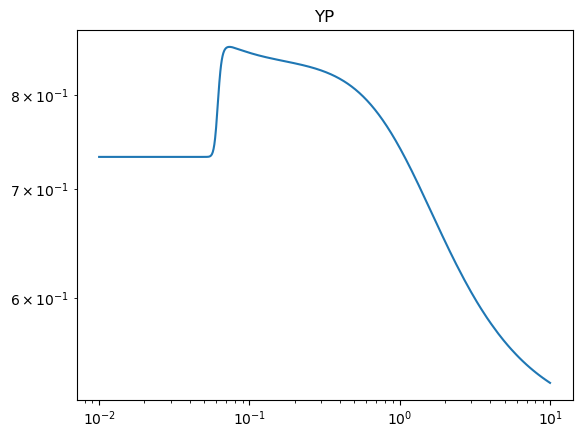

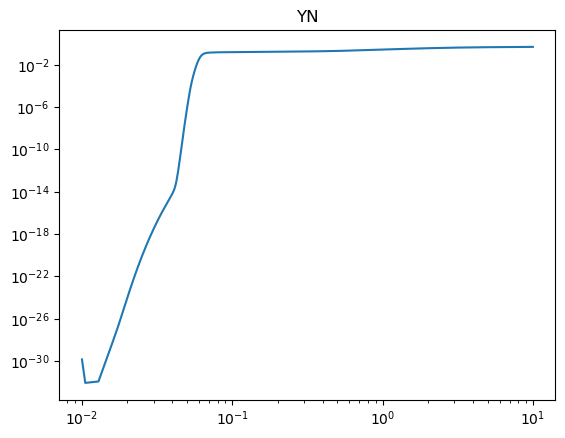

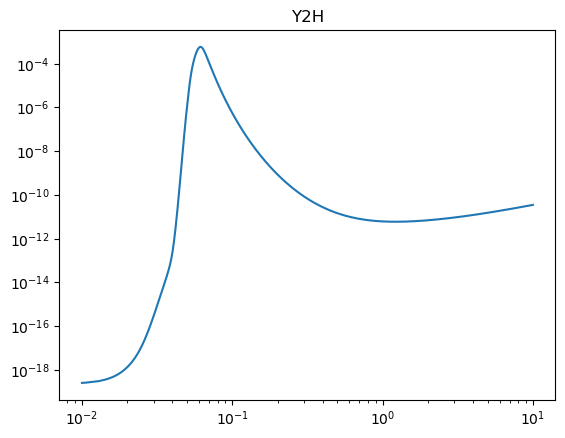

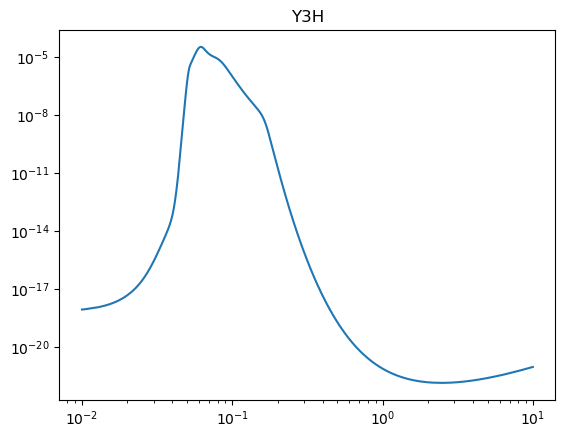

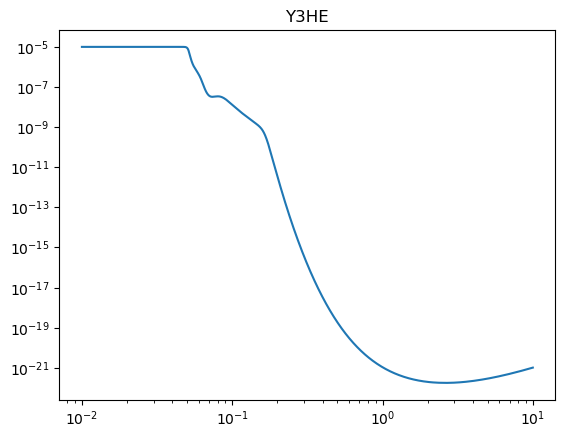

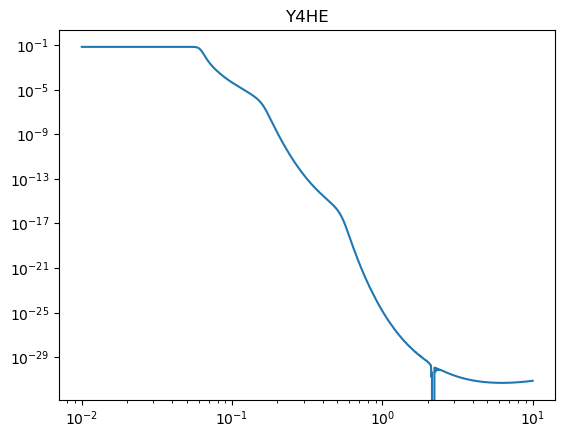

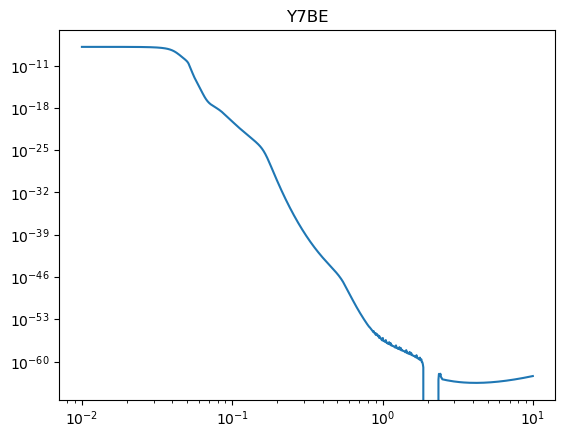

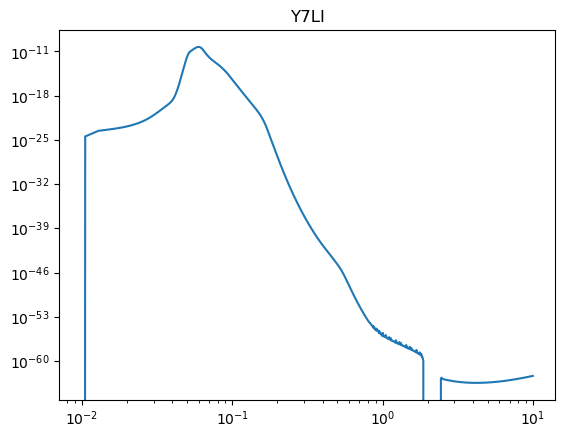

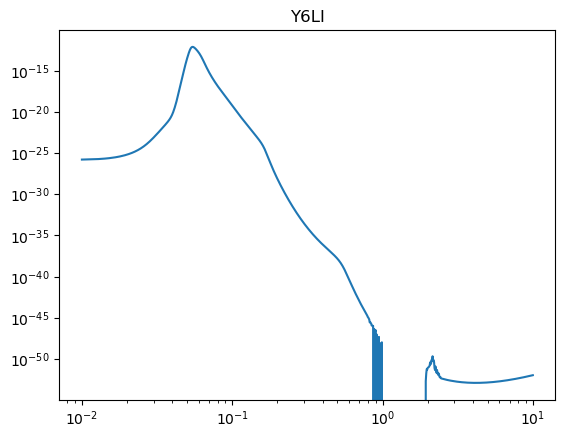

<Figure size 640x480 with 0 Axes>

In [97]:
plt.figure()
Tcm=1/a_total
YP = np.zeros(len(a_total))
YN = np.zeros(len(a_total)) 
Y2H = np.zeros(len(a_total)) 
Y3H = np.zeros(len(a_total)) 
Y3HE = np.zeros(len(a_total)) 
Y4HE = np.zeros(len(a_total)) 
Y7BE = np.zeros(len(a_total)) 
Y7LI = np.zeros(len(a_total)) 
Y6LI = np.zeros(len(a_total)) 
nseval=np.zeros((9,len(a_total)))
    
for i in range(len(a_total)):
    
    YP[i] = y_total[i,3]
    YN[i] = y_total[i,4]
    Y2H[i] = y_total[i,5]
    Y3H[i] = y_total[i,6]
    Y3HE[i] = y_total[i,7]
    Y4HE[i] = y_total[i,8]
    Y7BE[i] = y_total[i,9]
    Y7LI[i] = y_total[i,10]
    Y6LI[i] = y_total[i,11]

    nseval[:,i] = nse.nse(y_total[i,0] , y_total[i,2] , y_total[i,3] , y_total[i,4])
plt.figure()
plt.loglog(Tcm,YP)
plt.title("YP")
plt.figure()
plt.loglog(Tcm,YN)
plt.title("YN")
plt.figure()
plt.loglog(Tcm,Y2H)
plt.title("Y2H")
plt.figure()
plt.loglog(Tcm,Y3H )
plt.title("Y3H")
plt.figure()
plt.loglog(Tcm,Y3HE )
plt.title("Y3HE")
plt.figure()
plt.loglog(Tcm,Y4HE )
plt.title("Y4HE")
plt.figure()
plt.loglog(Tcm, Y7BE)
plt.title("Y7BE")
plt.figure()
plt.loglog(Tcm,Y7LI )
plt.title("Y7LI")
plt.figure()
plt.loglog(Tcm,Y6LI)
plt.title("Y6LI")
plt.figure()

In [110]:
def schramm(eta_final):
    a_total, y_total  = a_total_y_tot(6.1e-10)
    abundances_final = der.sep(y_total[-1,:])
    HE_mass_fraction = 4*Y4HE
    DH = Y2H/YP
    LI7H = (Y7LI+Y7LI)/YP
    HE3H = (Y3HE+Y3H)/YP
    LI6H = Y6LI/YP
    
    return HE_mass_fraction, DH, LI7H, HE3H, LI6H

In [134]:
HE_mass_fraction, DH, LI7H, HE3H, LI6H = schramm(6.1e-10)
print(HE_mass_fraction)

True
True
[2.99989504e-31 2.99271834e-31 2.98334522e-31 ... 2.67298409e-01
 2.67298409e-01 2.67298409e-01]


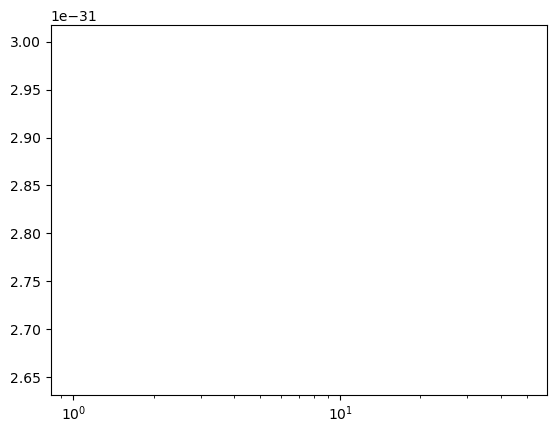

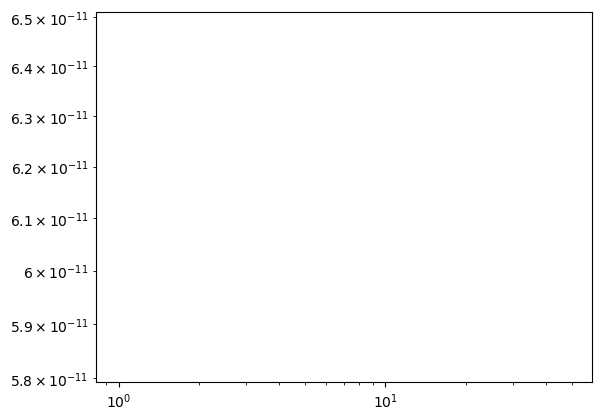

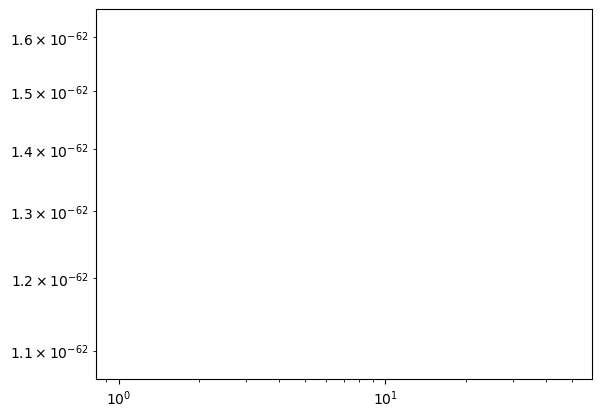

In [144]:
eta_final = np.linspace(1e-10,1e-9)

plt.figure()
for i in range(len(eta_final)):
    plt.semilogx(i,HE_mass_fraction[i])

plt.figure()
for i in range(len(eta_final)):
    plt.loglog(i,DH[i])

   
plt.figure()
for i in range(len(eta_final)):
    plt.loglog(i,LI7H[i])
  